In [5]:
!pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

In [10]:
fp_avail="gs://agntworks-data-dev/sandbox/experiments/Available Flights Last 18 mos.xlsx"
fp_comp="gs://agntworks-data-dev/sandbox/experiments/Completed-Flights-2016.xlsx"
fp_quotes="gs://agntworks-data-dev/sandbox/experiments/XODM-quotes-trips-2016.xlsx"

avail = pd.read_excel(fp_avail)
completed = pd.read_excel(fp_comp)
quotes_2016 = pd.read_excel(fp_quotes, sheet_name='2016')

In [11]:
# Quick schema + sample
for name, df in [('avail', avail), ('completed', completed), ('quotes_2016', quotes_2016)]:
    print('\n' + '='*90)
    print(name, df.shape)
    print('Columns:', list(df.columns))
    display(df.head(5))
    # missingness top 15
    miss = (df.isna().mean().sort_values(ascending=False) * 100).round(1)
    display(miss.head(15).to_frame('missing_%'))
    # dtypes
    display(df.dtypes.to_frame('dtype').T)



avail (552, 3)
Columns: ['date', 'sold', 'available']


,date,sold,available
0,2015-01-12,19,1
1,2015-01-13,17,2
2,2015-01-14,23,1
3,2015-01-15,29,0
4,2015-01-16,33,3


,missing_%
date,0.0
sold,0.0
available,0.0


,date,sold,available
dtype,datetime64[ns],int64,int64



completed (12806, 32)
Columns: ['Quote_Number', 'Trip_Number', 'Trip_Legs_ID', 'Leg_Count', 'Leg_Number', 'DHflag', 'PAX_Count', 'Dep_ICAO', 'Dep_Lat', 'Dep_Long', 'Dep_region', 'Arr_ICAO', 'Arr_Lat', 'Arr_Long', 'Arr_region', 'Trip_type_code', 'Trip_Purpose', 'Aircraft_ID', 'Aircraft_Type_ID', 'Dep_Date_Actual_GMT', 'Dep_Time_Actual_GMT', 'Arr_Date_Actual_GMT', 'Arr_Time_Actual_GMT', 'TO_Time_Act_GMT', 'Land_Time_Act_GMT', 'Statute_Miles', 'Quote_Total_Cost', 'Equivalent_Rate_Cost', 'AC_Cost_Total', 'Owner_AC_Cost', 'Owner_AC_Cost_Fixed', 'Requester_Name_Key']


...

,Quote_Number,Trip_Number,Trip_Legs_ID,Leg_Count,Leg_Number,DHflag,PAX_Count,Dep_ICAO,Dep_Lat,Dep_Long,...,Arr_Time_Actual_GMT,TO_Time_Act_GMT,Land_Time_Act_GMT,Statute_Miles,Quote_Total_Cost,Equivalent_Rate_Cost,AC_Cost_Total,Owner_AC_Cost,Owner_AC_Cost_Fixed,Requester_Name_Key
dtype,int64,int64,object,int64,int64,int64,int64,object,int64,int64,...,object,object,object,int64,float64,float64,float64,float64,int64,object



quotes_2016 (22708, 59)
Columns: ['ID', 'Quote_ID', 'Confirmation_Number', 'Date_Quoted', 'PAX_ID', 'Trip_ID', 'Trip_KID_Date', 'Trip_Number', 'Trip_Status', 'qTrip_type_code', 'tRate_Type_Code', 'tDivision', 'tDept', 'Reason_Not_Booked', 'qRate_Type_Code', 'Trip_Purpose', 'Aircraft_Type_ID', 'Invoice_Number', 'Paid', 'Invoiced', 'Approved', 'Confirmed', 'Scheduled', 'Quoted_For_Company', 'Quote_Total_Cost', 'ETE_Quote', 'EFT_Quote', 'PaxFT', 'DHFT', 'tripBT', 'tripFT', 'Aircraft_ID', 'Company_Code', 'Scheduled_Date', 'Trip_Departure_Date', 'Trip_Arrival_Date', 'Percent_Discount', 'Quote_Status', 'Quoted_Route', 'Live_Leg_City_Pairs', 'Invoice_Date', 'Equivalent_Rate_Cost', 'Aircraft_Company_Code', 'Aircraft_Rate', 'DHRate', 'DHFT.1', 'DHBT', 'DHTaxi', 'Aircraft_Cost_Rate_Ft', 'Pass_FT_Fixed', 'Client_Invoice_Comment', 'Base_Code', 'Last_Update_Date', 'Payment_1', 'Payment_Date_1', 'Payment_Type_1', 'AC_Cost_Total', 'Owner_AC_Cost', 'Owner_AC_Cost_Fixed']


,ID,Quote_ID,Confirmation_Number,Date_Quoted,PAX_ID,Trip_ID,Trip_KID_Date,Trip_Number,Trip_Status,qTrip_type_code,...,Pass_FT_Fixed,Client_Invoice_Comment,Base_Code,Last_Update_Date,Payment_1,Payment_Date_1,Payment_Type_1,AC_Cost_Total,Owner_AC_Cost,Owner_AC_Cost_Fixed
0,362002,423681001GEOA08,568956,2015-12-31,3939244FOUL1871,0,NaT,NaN,NaN,RETA,...,0,0,0,2015-12-31,0.0,NaT,0,24000.0,0.0,0
1,362003,423681017GEOA08,568957,2015-12-31,421851225STEB01,423681017GEOA015,2015-12-31,174284.0,Cancelled,WHSL,...,0,0,0,2016-01-01,0.0,NaT,0,0.0,0.0,0
2,362005,423681029GEOA08,568958,2015-12-31,41210923STEB01,0,NaT,NaN,NaN,RETA,...,0,0,120,2015-12-31,0.0,NaT,0,72750.0,0.0,0
3,362004,423681030SERD08,568959,2015-12-31,39552284MURC01,423681030SERD015,2015-12-31,174295.0,Completed,WHSL,...,0,0,0,2016-01-13,12937.5,2016-01-06,102,20350.0,0.0,0
4,362006,423681055GEOA08,568960,2015-12-31,415961361GEOA01,0,NaT,NaN,NaN,RETA,...,0,0,120,2015-12-31,0.0,NaT,0,38850.0,0.0,0


,missing_%
tRate_Type_Code,99.9
Reason_Not_Booked,95.4
Payment_Date_1,82.2
Trip_KID_Date,72.7
Trip_Status,72.7
tDivision,72.7
tDept,72.7
tripFT,72.7
tripBT,72.7
Trip_Number,72.7


,ID,Quote_ID,Confirmation_Number,Date_Quoted,PAX_ID,Trip_ID,Trip_KID_Date,Trip_Number,Trip_Status,qTrip_type_code,...,Pass_FT_Fixed,Client_Invoice_Comment,Base_Code,Last_Update_Date,Payment_1,Payment_Date_1,Payment_Type_1,AC_Cost_Total,Owner_AC_Cost,Owner_AC_Cost_Fixed
dtype,int64,object,int64,datetime64[ns],object,object,datetime64[ns],float64,object,object,...,int64,int64,int64,datetime64[ns],float64,datetime64[ns],int64,float64,float64,int64


In [13]:
def _to_timedelta(s: pd.Series) -> pd.Series:
    # Handles strings like '02:44:00' and missing values
    return pd.to_timedelta(s.astype('string'), errors='coerce')


completed_leg = completed.copy()

# Parse actual departure/arrival datetimes (date + time), both are in GMT fields
completed_leg['Dep_DT_GMT'] = pd.to_datetime(completed_leg['Dep_Date_Actual_GMT']) + _to_timedelta(completed_leg['Dep_Time_Actual_GMT'])
completed_leg['Arr_DT_GMT'] = pd.to_datetime(completed_leg['Arr_Date_Actual_GMT']) + _to_timedelta(completed_leg['Arr_Time_Actual_GMT'])

# Compute block time per leg (minutes); negative/zero becomes NaN (data issues / midnight crossover mishandling)
block_min = (completed_leg['Arr_DT_GMT'] - completed_leg['Dep_DT_GMT']).dt.total_seconds() / 60
completed_leg['Block_Min'] = block_min.where(block_min > 0)

# Basic numeric sanity
for c in ['Statute_Miles', 'PAX_Count', 'DHflag', 'Leg_Number', 'Leg_Count']:
    completed_leg[c] = pd.to_numeric(completed_leg[c], errors='coerce')

# --- Aggregate to trip level (Trip_Number) ---
# We use sums for distance/time and max for leg_count; pax is tricky leg-level, use max as proxy for trip pax load.
trip_agg = (
    completed_leg
    .groupby('Trip_Number', dropna=False)
    .agg(
        n_legs=('Trip_Legs_ID', 'nunique'),
        leg_count_max=('Leg_Count', 'max'),
        miles_total=('Statute_Miles', 'sum'),
        block_min_total=('Block_Min', 'sum'),
        pax_max=('PAX_Count', 'max'),
        dh_legs=('DHflag', 'sum'),
        miles_dh=('Statute_Miles', lambda x: x[completed_leg.loc[x.index, 'DHflag'].fillna(0).astype(int)==1].sum()),
        dep_dt_min=('Dep_DT_GMT', 'min'),
        arr_dt_max=('Arr_DT_GMT', 'max'),
        dep_icao_first=('Dep_ICAO', 'first'),
        arr_icao_last=('Arr_ICAO', 'last'),
        trip_type_code=('Trip_type_code', 'first'),
        trip_purpose=('Trip_Purpose', 'first'),
        aircraft_type_id=('Aircraft_Type_ID', 'first'),
        aircraft_id=('Aircraft_ID', 'first'),
        quote_total_cost=('Quote_Total_Cost', 'first'),
        eq_rate_cost=('Equivalent_Rate_Cost', 'first'),
        ac_cost_total=('AC_Cost_Total', 'first'),
        owner_ac_cost=('Owner_AC_Cost', 'first'),
    )
    .reset_index()
)

# Derived operational ratios (often key pricing levers)
trip_agg['dh_share_miles'] = (trip_agg['miles_dh'] / trip_agg['miles_total']).replace([np.inf, -np.inf], np.nan)
trip_agg['block_hr_total'] = trip_agg['block_min_total'] / 60
trip_agg['speed_mph'] = (trip_agg['miles_total'] / (trip_agg['block_hr_total'])).replace([np.inf, -np.inf], np.nan)
trip_agg['cost_per_mile_actual'] = (trip_agg['quote_total_cost'] / trip_agg['miles_total']).replace([np.inf, -np.inf], np.nan)
trip_agg['cost_per_block_hr_actual'] = (trip_agg['quote_total_cost'] / trip_agg['block_hr_total']).replace([np.inf, -np.inf], np.nan)
trip_agg['margin_vs_ac_cost'] = trip_agg['quote_total_cost'] - trip_agg['ac_cost_total']
trip_agg['margin_pct_vs_ac_cost'] = (trip_agg['margin_vs_ac_cost'] / trip_agg['quote_total_cost']).replace([np.inf, -np.inf], np.nan)

# Add calendar fields (seasonality is a common aviation pricing driver)
trip_agg['dep_date'] = trip_agg['dep_dt_min'].dt.date
trip_agg['dep_month'] = trip_agg['dep_dt_min'].dt.to_period('M').astype('string')
trip_agg['dep_dow'] = trip_agg['dep_dt_min'].dt.day_name()

# --- Join to quotes_2016 for quote/status fields (trip-level) ---
quotes_trip = quotes_2016.copy()
quotes_trip['Trip_Number'] = pd.to_numeric(quotes_trip['Trip_Number'], errors='coerce')

# One Trip_Number can appear multiple times in quotes (re-quotes, updates). Keep latest by Last_Update_Date.
quotes_trip = quotes_trip.sort_values('Last_Update_Date').drop_duplicates(subset=['Trip_Number'], keep='last')

trip = trip_agg.merge(
    quotes_trip[[
        'Trip_Number','Trip_Status','Date_Quoted','Scheduled_Date','Trip_Departure_Date','Trip_Arrival_Date',
        'Percent_Discount','Quote_Status','Quoted_Route','Live_Leg_City_Pairs','qTrip_type_code','qRate_Type_Code',
        'Aircraft_Rate','DHRate','Company_Code','Quoted_For_Company'
    ]],
    on='Trip_Number',
    how='left'
)

# Quick preview
print('Trip-level dataset:', trip.shape)
display(trip.head(5))

# Basic missingness for key analysis fields
key_cols = [
    'miles_total','block_hr_total','pax_max','dh_share_miles','quote_total_cost','ac_cost_total','margin_pct_vs_ac_cost',
    'Trip_Status','Quote_Status','Percent_Discount','qRate_Type_Code','Aircraft_Rate','DHRate','dep_month'
]
miss_key = (trip[key_cols].isna().mean().sort_values(ascending=False) * 100).round(1)
display(miss_key.to_frame('missing_%'))

# Sanity summaries for potential anomalies
summ = trip[['miles_total','block_hr_total','speed_mph','dh_share_miles','cost_per_mile_actual','margin_pct_vs_ac_cost']].describe(percentiles=[.01,.05,.5,.95,.99]).T
summ = summ.round(3)
display(summ)

Trip-level dataset: (6167, 45)


,Trip_Number,n_legs,leg_count_max,miles_total,block_min_total,pax_max,dh_legs,miles_dh,dep_dt_min,arr_dt_max,...,Percent_Discount,Quote_Status,Quoted_Route,Live_Leg_City_Pairs,qTrip_type_code,qRate_Type_Code,Aircraft_Rate,DHRate,Company_Code,Quoted_For_Company
0,157565,3,3,4382,698.0,4,1,1227,2016-01-01 23:37:00,2016-01-03 03:15:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,162215,6,7,6771,932.0,2,3,2501,2016-01-10 14:56:00,2016-01-17 23:16:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,162216,5,5,4583,626.0,2,1,163,2016-02-01 12:40:00,2016-02-11 22:12:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,162484,3,3,8211,950.0,9,0,0,2016-04-08 04:40:00,2016-04-18 00:30:00,...,0.0,Invoiced - Ready to Export,KOAK-MBPV MBPV-TVSC TVSC-KOAK,KOAK-MBPV MBPV-TVSC TVSC-KOAK,RETA,CHTR,9071.39,0.0,1.0,MacGregor & Mary Read Revocable Trust - PRF6
4,165417,1,1,1528,183.0,16,0,0,2016-01-02 18:42:00,2016-01-02 21:45:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing_%
margin_pct_vs_ac_cost,23.4
qRate_Type_Code,18.9
Trip_Status,18.6
Quote_Status,18.6
Aircraft_Rate,18.6
Percent_Discount,18.6
DHRate,18.6
dh_share_miles,2.4
ac_cost_total,0.0
block_hr_total,0.0


,count,mean,std,min,1%,5%,50%,95%,99%,max
miles_total,6167.0,1947.889,1644.349,0.000,0.00,146.900,1633.000,5138.000,6827.860,20510.000
block_hr_total,6167.0,4.778,3.638,0.000,0.00,0.800,4.067,11.662,15.817,47.850
speed_mph,6092.0,372.851,100.436,0.000,0.00,177.887,395.739,492.497,530.074,1101.496
dh_share_miles,6022.0,0.177,0.294,0.000,0.00,0.000,0.000,1.000,1.000,1.000
cost_per_mile_actual,6022.0,13.822,31.736,-0.281,0.00,0.000,12.084,31.399,60.443,1249.438
margin_pct_vs_ac_cost,4724.0,0.099,0.258,-2.911,-0.77,-0.409,0.170,0.366,0.474,1.000


In [15]:
num_cols = [
    'miles_total','block_hr_total','pax_max','dh_share_miles',
    'quote_total_cost','ac_cost_total','cost_per_mile_actual','cost_per_block_hr_actual',
    'margin_vs_ac_cost','margin_pct_vs_ac_cost','speed_mph','n_legs'
]
cat_cols = ['Trip_Status','Quote_Status','qTrip_type_code','qRate_Type_Code','trip_type_code','trip_purpose','dep_month','dep_dow']

# --- Basic duplicates / null sanity ---
print('Trip rows:', len(trip))
print('Unique Trip_Number:', trip['Trip_Number'].nunique())

# --- Numeric summaries with  percentiles ---
desc = trip[num_cols].describe(percentiles=[.01,.05,.1,.5,.9,.95,.99]).T

desc['missing_%'] = (trip[num_cols].isna().mean()*100).round(2)
desc['zero_%'] = ((trip[num_cols]==0).mean()*100).round(2)

display(desc.round(3))

Trip rows: 6167
Unique Trip_Number: 6167


,count,mean,std,min,1%,5%,10%,50%,90%,95%,99%,max,missing_%,zero_%
miles_total,6167.0,1947.889,1644.349,0.000,0.00,146.900,247.000,1633.000,4213.400,5138.000,6827.860,20510.000,0.00,2.35
block_hr_total,6167.0,4.778,3.638,0.000,0.00,0.800,1.083,4.067,9.783,11.662,15.817,47.850,0.00,1.22
pax_max,6167.0,3.424,2.618,0.000,0.00,0.000,0.000,3.000,7.000,8.000,10.000,21.000,0.00,10.54
dh_share_miles,6022.0,0.177,0.294,0.000,0.00,0.000,0.000,0.000,0.567,1.000,1.000,1.000,2.35,49.96
quote_total_cost,6167.0,25258.477,27896.820,-295.000,0.00,0.000,0.000,21974.000,54139.428,66748.493,99997.966,673872.350,0.00,23.40
ac_cost_total,6167.0,22380.436,24762.128,0.000,0.00,0.000,0.000,19408.500,45586.254,60953.817,89136.000,585380.020,0.00,23.56
cost_per_mile_actual,6022.0,13.822,31.736,-0.281,0.00,0.000,0.000,12.084,23.806,31.399,60.443,1249.438,2.35,21.06
cost_per_block_hr_actual,6092.0,4791.663,4270.404,-109.259,0.00,0.000,0.000,4944.820,8385.264,10089.259,16815.976,108923.782,1.22,22.20
margin_vs_ac_cost,6167.0,2878.041,7609.936,-37400.000,-15845.22,-8078.560,-4577.942,1754.010,11768.226,15979.589,23974.693,123472.550,0.00,23.43
margin_pct_vs_ac_cost,4724.0,0.099,0.258,-2.911,-0.77,-0.409,-0.212,0.170,0.323,0.366,0.474,1.000,23.40,0.03


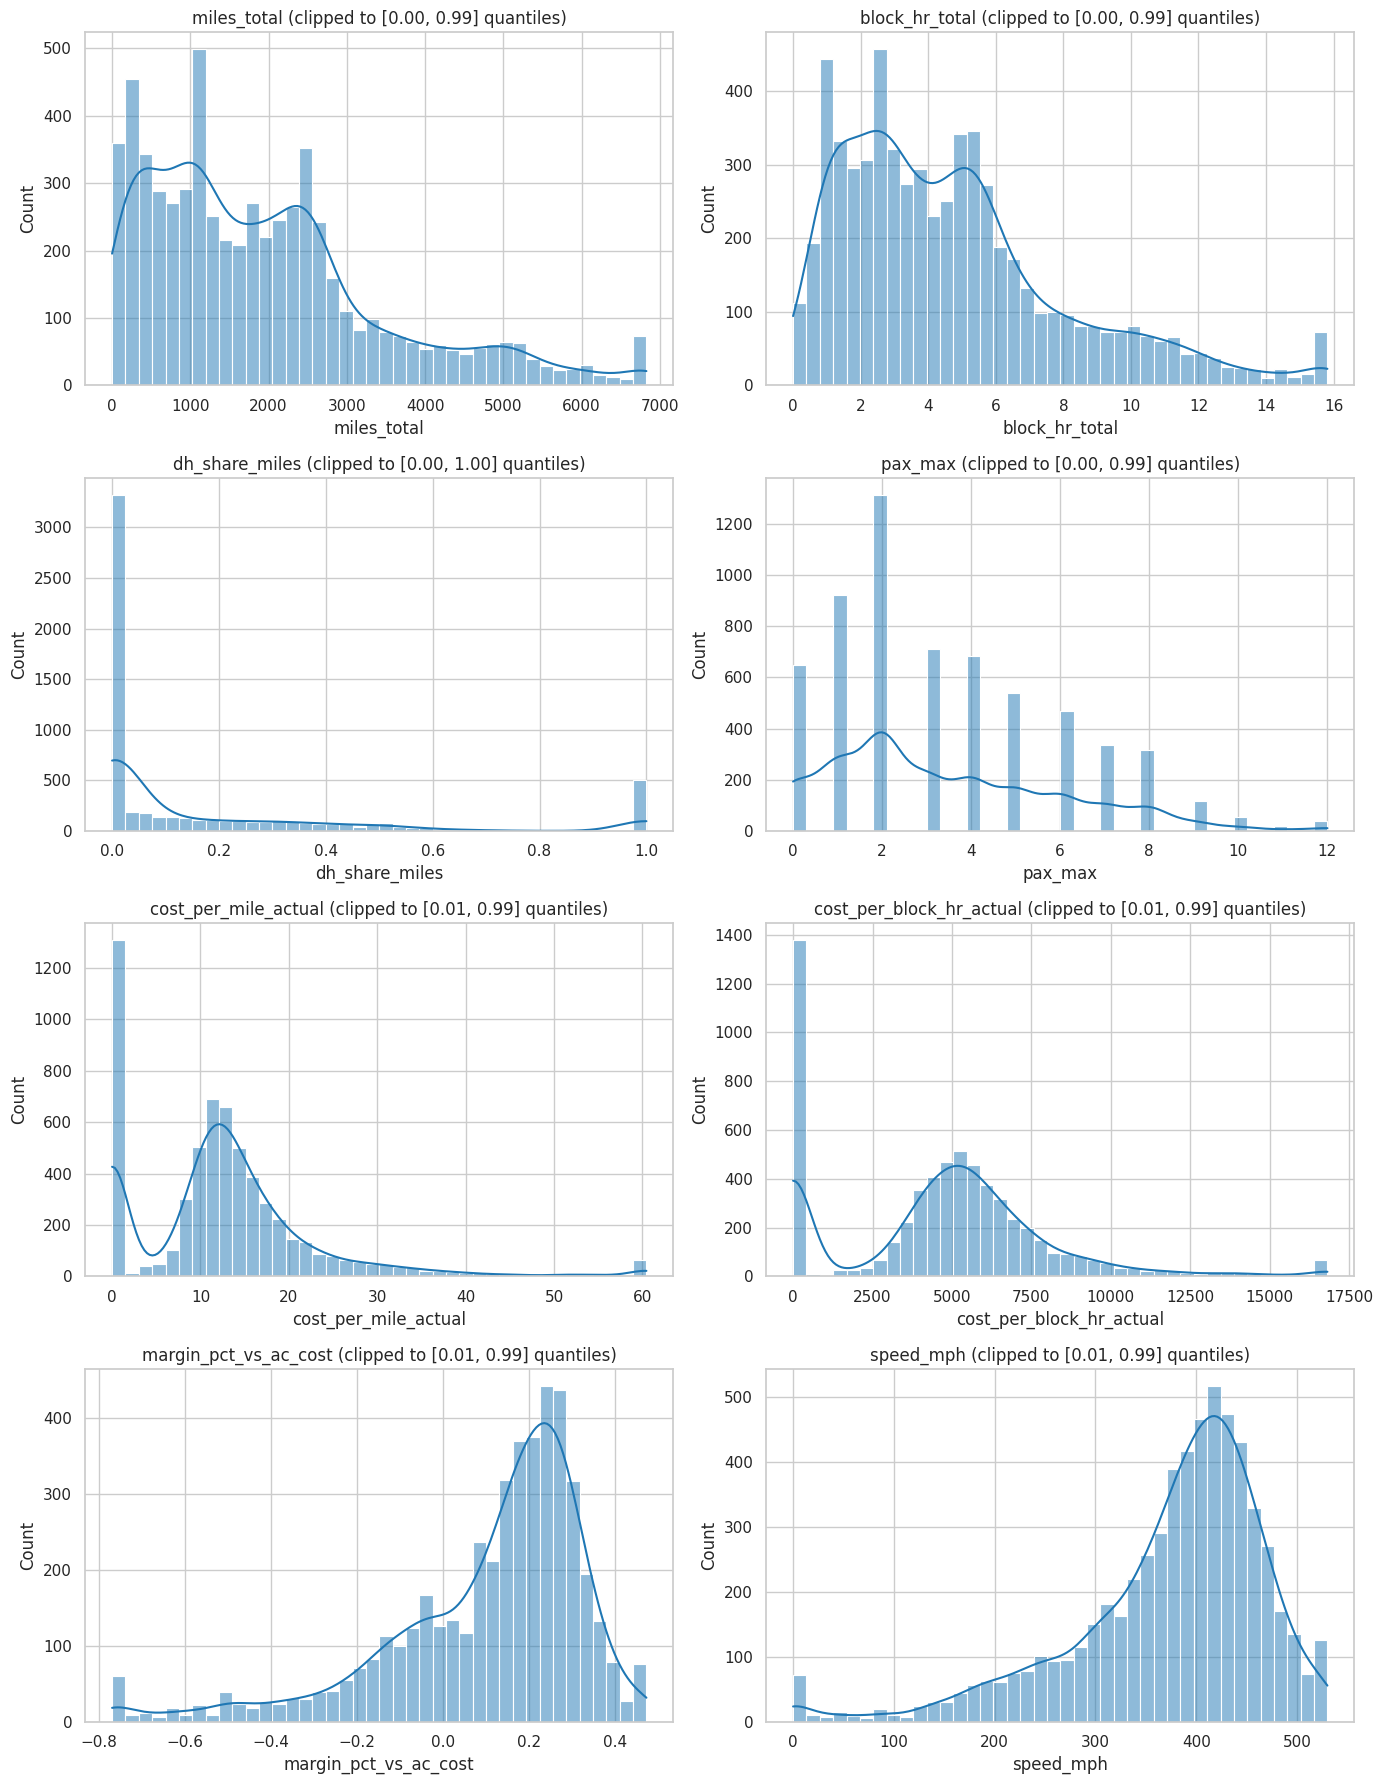

In [16]:

# --- Distribution plots (winsorized view for readability, plus raw outlier counts) ---
plot_specs = [
    ('miles_total', (0, 0.99)),
    ('block_hr_total', (0, 0.99)),
    ('dh_share_miles', (0, 1.0)),
    ('pax_max', (0, 0.995)),
    ('cost_per_mile_actual', (0.01, 0.99)),
    ('cost_per_block_hr_actual', (0.01, 0.99)),
    ('margin_pct_vs_ac_cost', (0.01, 0.99)),
    ('speed_mph', (0.01, 0.99)),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.ravel()

for ax, (col, (qlo, qhi)) in zip(axes, plot_specs):
    s = trip[col].dropna()
    lo = s.quantile(qlo) if qlo > 0 else s.min()
    hi = s.quantile(qhi)
    s_clip = s.clip(lower=lo, upper=hi)
    sns.histplot(s_clip, bins=40, kde=True, ax=ax, color='#1f77b4')
    ax.set_title(f"{col} (clipped to [{qlo:.2f}, {qhi:.2f}] quantiles)")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

In [17]:
# --- Categorical distributions (top levels) ---
for col in cat_cols:
    if col not in trip.columns:
        continue
    vc = trip[col].astype('string').fillna('NA').value_counts(dropna=False)
    print("\n" + "="*90)
    print(f"{col} (top 15 of {vc.shape[0]} levels)")
    display(vc.head(15).to_frame('count'))


Trip_Status (top 15 of 4 levels)


,count
Trip_Status,
Completed,4889
NA,1150
Scheduled,79
Cancelled,49



Quote_Status (top 15 of 7 levels)


,count
Quote_Status,
Invoiced - Ready to Export,3825
NA,1150
Scheduled,1016
Cancelled,131
Approved,20
Ready,15
Paid - Exported to Accounting,10



qTrip_type_code (top 15 of 8 levels)


...

,count
trip_purpose,
CHTR,1061
C0NS,903
JSDH,777
NA,696
CSNS,458
C0NB,451
XSDS,405
XSSS,246
X0DS,232



dep_month (top 15 of 6 levels)


,count
dep_month,
2016-06,1107
2016-05,1069
2016-03,1049
2016-01,1015
2016-04,999
2016-02,928



dep_dow (top 15 of 7 levels)


,count
dep_dow,
Friday,956
Thursday,929
Monday,905
Wednesday,875
Saturday,858
Tuesday,829
Sunday,815


In [18]:
# --- Identify operational anomalies using aviation-informed rules of thumb ---
# (1) zero miles but nonzero cost
anom1 = trip[(trip['miles_total']==0) & (trip['quote_total_cost']>0)].copy()
# (2) extremely high cost per mile (top 0.5%)
cpm = trip['cost_per_mile_actual'].replace([np.inf,-np.inf], np.nan)
th_cpm = cpm.quantile(0.995)
anom2 = trip[cpm > th_cpm].copy()
# (3) implausible speeds (e.g., > 650 mph) - jets can be ~450-520 mph cruise; >650 often indicates bad times
spd = trip['speed_mph'].replace([np.inf,-np.inf], np.nan)
anom3 = trip[spd > 650].copy()
# (4) margin pct outside [-1,1] already possible but extreme negatives suggest mismatched cost fields
mp = trip['margin_pct_vs_ac_cost']
anom4 = trip[mp < mp.quantile(0.01)].copy()

print("\nOperational anomaly counts")
print({
    'zero_miles_positive_cost': len(anom1),
    'top_0.5%_cost_per_mile': len(anom2),
    'speed_gt_650_mph': len(anom3),
    'bottom_1%_margin_pct': len(anom4),
})



Operational anomaly counts
{'zero_miles_positive_cost': 1, 'top_0.5%_cost_per_mile': 31, 'speed_gt_650_mph': 8, 'bottom_1%_margin_pct': 47}


In [19]:
cols_show = ['Trip_Number','dep_dt_min','arr_dt_max','n_legs','miles_total','block_hr_total','speed_mph','dh_share_miles',
             'quote_total_cost','ac_cost_total','cost_per_mile_actual','cost_per_block_hr_actual','margin_pct_vs_ac_cost',
             'Trip_Status','Quote_Status','qRate_Type_Code','Quoted_For_Company','Quoted_Route']

for title, df_ex in [
    ('Zero miles but positive cost (sample)', anom1),
    ('Very high cost per mile (sample)', anom2),
    ('Implausible speed > 650 mph (sample)', anom3),
    ('Very negative margin pct (sample)', anom4),
]:
    print("\n" + "-"*90)
    print(title)
    display(df_ex[ [c for c in cols_show if c in df_ex.columns] ].head(10))


------------------------------------------------------------------------------------------
Zero miles but positive cost (sample)


,Trip_Number,dep_dt_min,arr_dt_max,n_legs,miles_total,block_hr_total,speed_mph,dh_share_miles,quote_total_cost,ac_cost_total,cost_per_mile_actual,cost_per_block_hr_actual,margin_pct_vs_ac_cost,Trip_Status,Quote_Status,qRate_Type_Code,Quoted_For_Company,Quoted_Route
374,174003,2016-01-01 01:05:00,2016-01-01 01:05:00,1,0,0.0,NaN,NaN,25000.0,40150.0,NaN,NaN,-0.606,NaN,NaN,NaN,NaN,NaN



------------------------------------------------------------------------------------------
Very high cost per mile (sample)


,Trip_Number,dep_dt_min,arr_dt_max,n_legs,miles_total,block_hr_total,speed_mph,dh_share_miles,quote_total_cost,ac_cost_total,cost_per_mile_actual,cost_per_block_hr_actual,margin_pct_vs_ac_cost,Trip_Status,Quote_Status,qRate_Type_Code,Quoted_For_Company,Quoted_Route
246,173346,2016-01-03 17:00:00,2016-01-03 19:36:00,2,271,2.116667,128.031496,0.0,24495.81,22176.82,90.390443,11572.823622,0.094669,NaN,NaN,NaN,NaN,NaN
290,173669,2016-01-12 15:50:00,2016-01-12 16:59:00,1,190,1.150000,165.217391,0.0,29000.50,23100.00,152.634211,25217.826087,0.203462,NaN,NaN,NaN,NaN,NaN
341,173906,2016-01-04 01:07:00,2016-01-04 02:09:00,1,337,1.033333,326.129032,0.0,30469.13,26000.00,90.412849,29486.254839,0.146677,NaN,NaN,NaN,NaN,NaN
550,174540,2016-01-07 22:39:00,2016-01-07 22:45:00,1,9,0.100000,90.000000,0.0,2924.67,2055.18,324.963333,29246.700000,0.297295,Completed,Invoiced - Ready to Export,CHTR,"Carroll, Jason Eastwick",KJRB-KLGA
789,174913,2016-01-13 00:30:00,2016-01-14 19:00:00,5,910,4.400000,206.818182,0.0,78238.84,61625.00,85.976747,17781.554545,0.212348,Completed,Invoiced - Ready to Export,CHTR,Lone Star Funds,KTEB-KBWI KIAD-KTTN KTTN-KRIC KRIC-KRDU KRDU-KCAE
898,175097,2016-06-30 20:33:00,2016-06-30 20:53:00,1,30,0.333333,90.000000,1.0,34000.00,36450.00,1133.333333,102000.000000,-0.072059,Scheduled,Scheduled,XSSB,MacGregor & Mary Read Revocable Trust - PRF6,KOAK-KACK
1309,175754,2016-02-04 21:47:00,2016-02-04 23:14:00,1,300,1.450000,206.896552,1.0,29345.80,22276.67,97.819333,20238.482759,0.240891,Completed,Cancelled,C0NS,Anthony Diaco - PRF5,KTEB-KBLM KBLM-K36U
2363,177548,2016-03-05 21:43:00,2016-03-05 22:21:00,1,93,0.633333,146.842105,0.0,10700.00,9040.00,115.053763,16894.736842,0.155140,Completed,Invoiced - Ready to Export,CHTR,"Caesars Enterprise Services, LLC (RETAIL)",KMMU-KACY
2711,178093,2016-03-14 19:55:00,2016-03-14 21:02:00,1,246,1.116667,220.298507,1.0,43447.88,29870.38,176.617398,38908.549254,0.312501,Completed,Cancelled,C0NB,Magellan Jets,KDFW-KROA KROA-KSRQ KSRQ-KFLL KFLL-MDPP MDPP-KOPF
3418,179296,2016-04-04 01:59:00,2016-04-04 02:38:00,1,100,0.650000,153.846154,1.0,20000.00,48950.00,200.000000,30769.230769,-1.447500,Completed,Cancelled,XSDS,Gores Group,PHOG-KVNY



------------------------------------------------------------------------------------------
Implausible speed > 650 mph (sample)


,Trip_Number,dep_dt_min,arr_dt_max,n_legs,miles_total,block_hr_total,speed_mph,dh_share_miles,quote_total_cost,ac_cost_total,cost_per_mile_actual,cost_per_block_hr_actual,margin_pct_vs_ac_cost,Trip_Status,Quote_Status,qRate_Type_Code,Quoted_For_Company,Quoted_Route
343,173931,2016-01-27 22:05:00,2016-01-27 23:40:00,1,1085,1.583333,685.263158,0.0,19260.22,17600.00,17.751355,12164.349474,0.086199,NaN,NaN,NaN,NaN,NaN
625,174660,2016-04-04 23:40:00,2016-04-08 19:25:00,4,7678,10.500000,731.238095,0.0,140728.82,122920.14,18.328838,13402.744762,0.126546,Completed,Invoiced - Ready to Export,CHTR,Niraj Shah - ICONIQ PRF4,KBED-EDDB EDDB-EGKB EGKB-EINN EINN-KBED
858,175028,2016-02-14 16:23:00,2016-02-16 18:07:00,2,6396,8.950000,714.636872,0.0,143783.00,127500.00,22.480144,16065.139665,0.113247,NaN,NaN,NaN,NaN,NaN
1370,175863,2016-01-29 00:04:00,2016-01-29 03:03:00,1,1954,2.983333,654.972067,0.0,22037.00,18500.02,11.277892,7386.703911,0.160502,Completed,Invoiced - Ready to Export,CHTR,Polar Company,KMMU-KSLC
2459,177703,2016-06-04 19:46:00,2016-06-05 00:39:00,2,4663,4.233333,1101.496063,0.0,82526.31,73848.07,17.698115,19494.403937,0.105157,Completed,Invoiced - Ready to Export,CHTR,Leach Capital LLC - PRF6,KPBI-KMHT KMHT-LFPB
3518,179472,2016-04-10 22:10:00,2016-04-11 00:00:00,1,1856,1.833333,1012.363636,0.0,39500.00,35000.00,21.282328,21545.454545,0.113924,Completed,Invoiced - Ready to Export,CHTR,Philip Rivers - PRF5,KECP-KCRQ
5362,182581,2016-06-13 12:50:00,2016-06-13 13:10:00,1,236,0.333333,708.000000,0.0,22517.66,16500.00,95.413814,67552.980000,0.267242,Completed,Invoiced - Ready to Export,CHTR,"Kordestani, Omid",LFPB-EGGW
5788,183356,2016-06-15 05:40:00,2016-06-15 06:05:00,1,331,0.416667,794.400000,0.0,7095.11,6000.00,21.435378,17028.264000,0.154347,Completed,Invoiced - Ready to Export,CHTR,"Coon, Jonathan Craig",KSMO-KSFO



------------------------------------------------------------------------------------------
Very negative margin pct (sample)


,Trip_Number,dep_dt_min,arr_dt_max,n_legs,miles_total,block_hr_total,speed_mph,dh_share_miles,quote_total_cost,ac_cost_total,cost_per_mile_actual,cost_per_block_hr_actual,margin_pct_vs_ac_cost,Trip_Status,Quote_Status,qRate_Type_Code,Quoted_For_Company,Quoted_Route
103,171192,2016-01-02 20:06:00,2016-01-03 16:54:00,2,1276,3.800000,335.789474,0.063480,16156.43,29650.0,12.661779,4251.692105,-0.835183,NaN,NaN,NaN,NaN,NaN
270,173531,2016-01-10 18:53:00,2016-01-11 21:45:00,3,2245,5.700000,393.859649,0.235635,18000.00,33000.0,8.017817,3157.894737,-0.833333,NaN,NaN,NaN,NaN,NaN
283,173630,2016-01-02 17:24:00,2016-01-02 19:36:00,1,887,2.200000,403.181818,0.000000,11605.08,22350.0,13.083517,5275.036364,-0.925881,NaN,NaN,NaN,NaN,NaN
584,174594,2016-01-09 18:47:00,2016-01-11 17:18:00,2,2196,5.466667,401.707317,0.000000,22000.00,44000.0,10.018215,4024.390244,-1.000000,Completed,Invoiced - Ready to Export,XSDS,Unity Jets,KMIA-KTEB KTEB-KMIA
707,174772,2016-01-17 15:54:00,2016-01-17 19:51:00,2,1268,3.200000,396.250000,0.041009,13000.00,26400.0,10.252366,4062.500000,-1.030769,Completed,Invoiced - Ready to Export,XSDS,Jet Linx Aviation,KSNA-KDAL
758,174861,2016-01-12 20:05:00,2016-01-13 02:45:00,2,1044,2.833333,368.470588,0.091954,12500.00,24750.0,11.973180,4411.764706,-0.980000,Completed,Invoiced - Ready to Export,XSDS,Unity Jets,KMIA-KLUK
921,175136,2016-01-16 17:36:00,2016-01-16 23:10:00,2,2298,4.800000,478.750000,0.158834,19500.00,35200.0,8.485640,4062.500000,-0.805128,Completed,Invoiced - Ready to Export,XSDS,Jets.com,KTUS-KIAD
1237,175658,2016-03-19 17:20:00,2016-03-19 21:16:00,1,1704,3.933333,433.220339,0.000000,14113.40,26400.0,8.282512,3588.152542,-0.870563,Completed,Invoiced - Ready to Export,XSDS,"Costa, Jose",KOPF-KAPA
1271,175706,2016-01-30 20:56:00,2016-01-31 20:07:00,3,1808,5.200000,347.692308,0.059181,19000.00,38500.0,10.508850,3653.846154,-1.026316,Completed,Cancelled,XSDS,"Pantzer, Jordan Matthew",TNCM-KTEB
1282,175720,2016-01-26 19:00:00,2016-01-27 00:15:00,1,2333,5.250000,444.380952,0.000000,9000.00,35200.0,3.857694,1714.285714,-2.911111,Completed,Invoiced - Ready to Export,XSDS,Jet Demands,KPBI-KSMO


In [20]:
trip_cln = trip.copy()

# Treat known problematic/undefined derived rates as NaN
trip_cln.loc[trip_cln['miles_total'] <= 0, ['cost_per_mile_actual']] = np.nan
trip_cln.loc[trip_cln['block_hr_total'] <= 0, ['cost_per_block_hr_actual', 'speed_mph']] = np.nan

# Remove obviously invalid financials for analysis of pricing (keep a copy for audit)
# Negative quote_total_cost is almost certainly reversal/credit; exclude for pricing model/EDA
trip_cln = trip_cln[trip_cln['quote_total_cost'] >= 0].copy()

# Focus on completed/invoiced trips when studying realized pricing vs ops drivers
# (Quotes table join is missing for ~18.6% of trips; completed legs exist regardless.)
trip_realized = trip_cln[trip_cln['Quote_Status'].fillna('NA').isin(['Invoiced - Ready to Export','Paid - Exported to Accounting'])].copy()

print('All trips:', trip.shape)
print('After nonnegative quote_total_cost:', trip_cln.shape)
print('Realized (invoiced/paid):', trip_realized.shape)


All trips: (6167, 45)
After nonnegative quote_total_cost: (6166, 45)
Realized (invoiced/paid): (3835, 45)


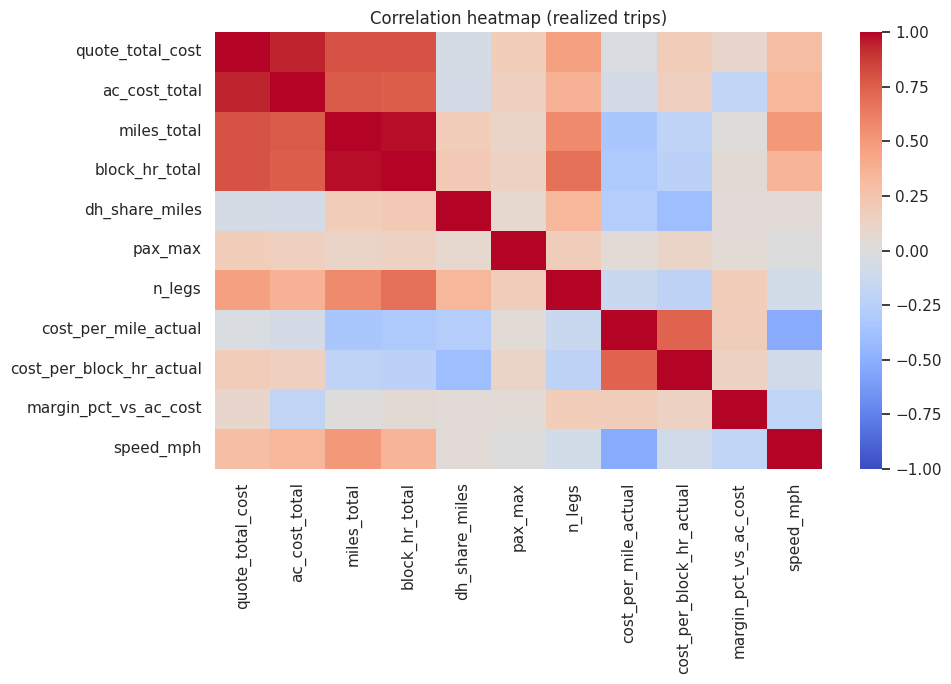

In [21]:
num_for_corr = [
    'quote_total_cost','ac_cost_total','miles_total','block_hr_total','dh_share_miles','pax_max','n_legs',
    'cost_per_mile_actual','cost_per_block_hr_actual','margin_pct_vs_ac_cost','speed_mph'
]

corr = trip_realized[num_for_corr].corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation heatmap (realized trips)')
plt.tight_layout()
plt.show()


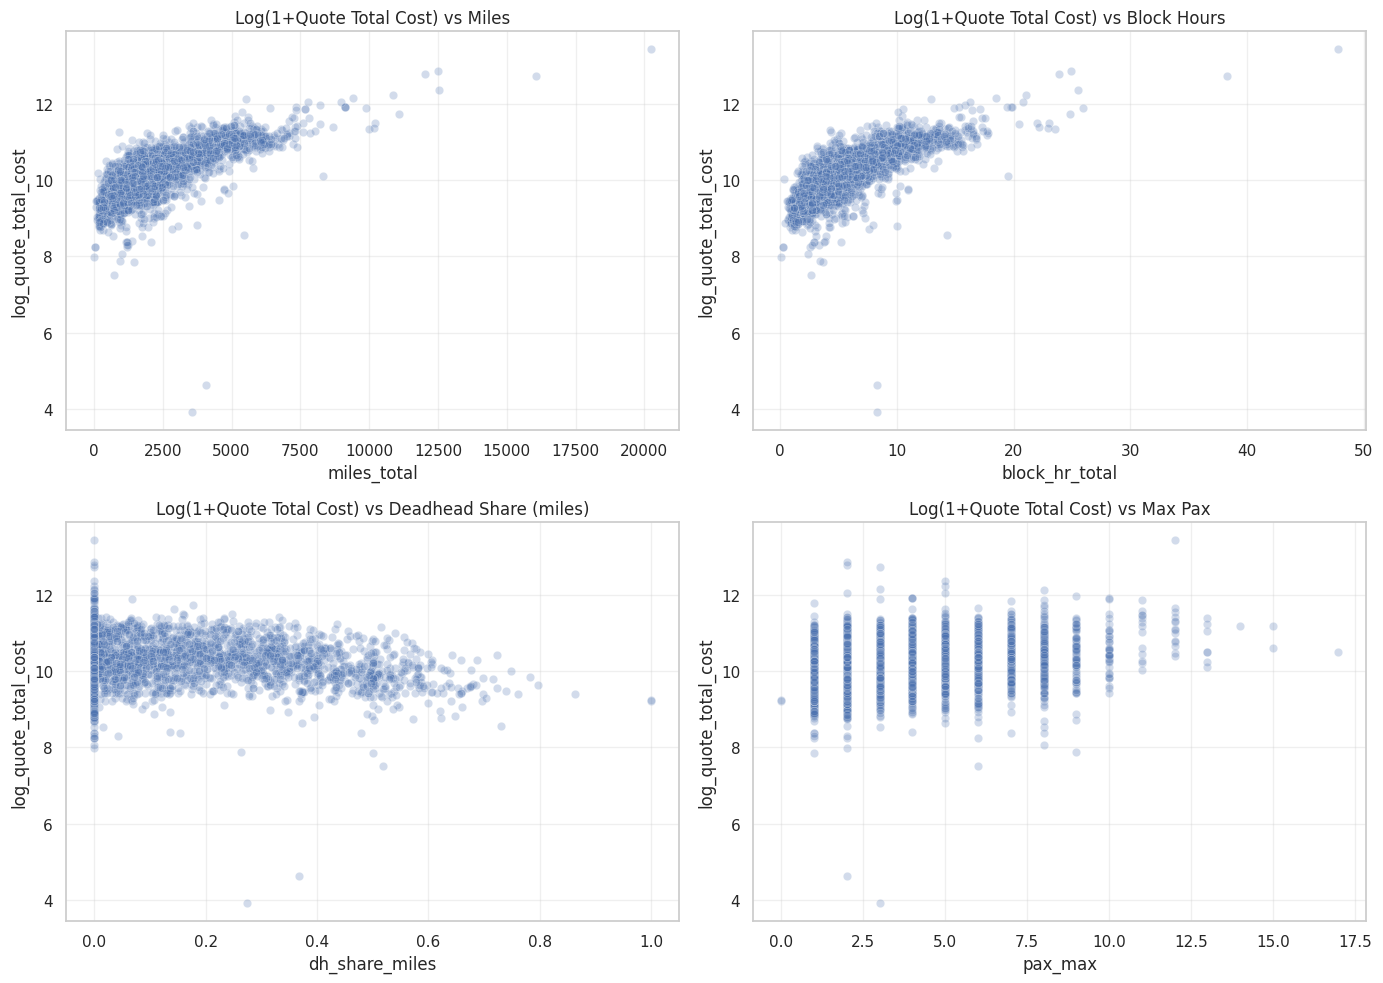

In [22]:
# --- Key bivariate plots: price vs operational drivers ---
# Use log scale for cost because of heavy right tail
plot_df = trip_realized.copy()
plot_df['log_quote_total_cost'] = np.log1p(plot_df['quote_total_cost'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=plot_df, x='miles_total', y='log_quote_total_cost', alpha=0.25, ax=axes[0,0])
axes[0,0].set_title('Log(1+Quote Total Cost) vs Miles')

sns.scatterplot(data=plot_df, x='block_hr_total', y='log_quote_total_cost', alpha=0.25, ax=axes[0,1])
axes[0,1].set_title('Log(1+Quote Total Cost) vs Block Hours')

sns.scatterplot(data=plot_df, x='dh_share_miles', y='log_quote_total_cost', alpha=0.25, ax=axes[1,0])
axes[1,0].set_title('Log(1+Quote Total Cost) vs Deadhead Share (miles)')

sns.scatterplot(data=plot_df, x='pax_max', y='log_quote_total_cost', alpha=0.25, ax=axes[1,1])
axes[1,1].set_title('Log(1+Quote Total Cost) vs Max Pax')

for ax in axes.ravel():
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


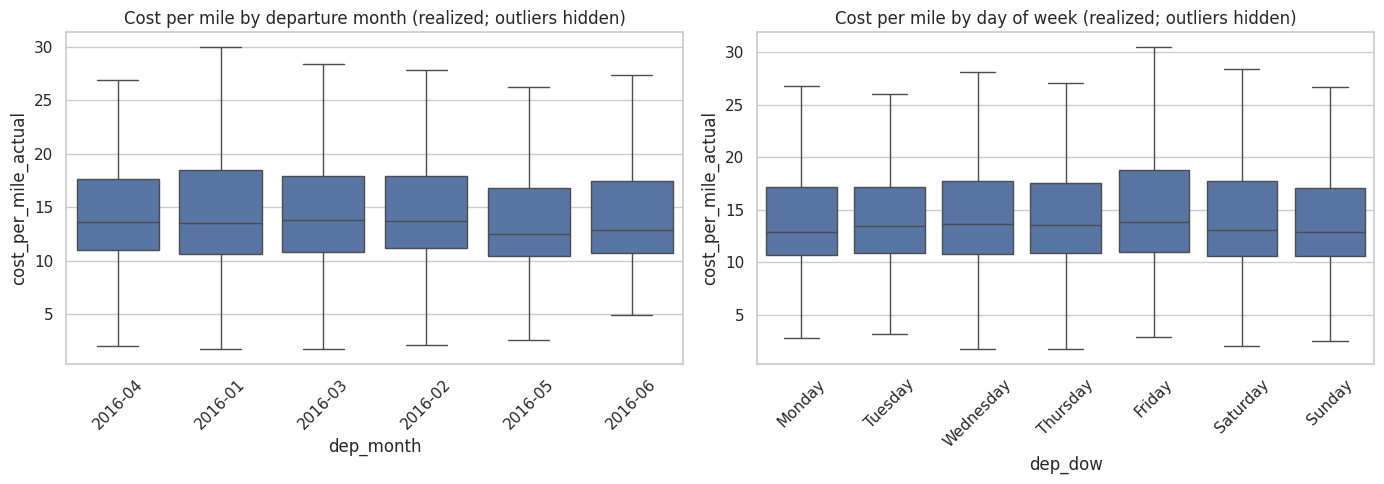

In [23]:
# --- Seasonality / weekday effects on unit economics (toggle candidates) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=plot_df, x='dep_month', y='cost_per_mile_actual', ax=axes[0], showfliers=False)
axes[0].set_title('Cost per mile by departure month (realized; outliers hidden)')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=plot_df, x='dep_dow', y='cost_per_mile_actual', ax=axes[1], showfliers=False,
            order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
axes[1].set_title('Cost per mile by day of week (realized; outliers hidden)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


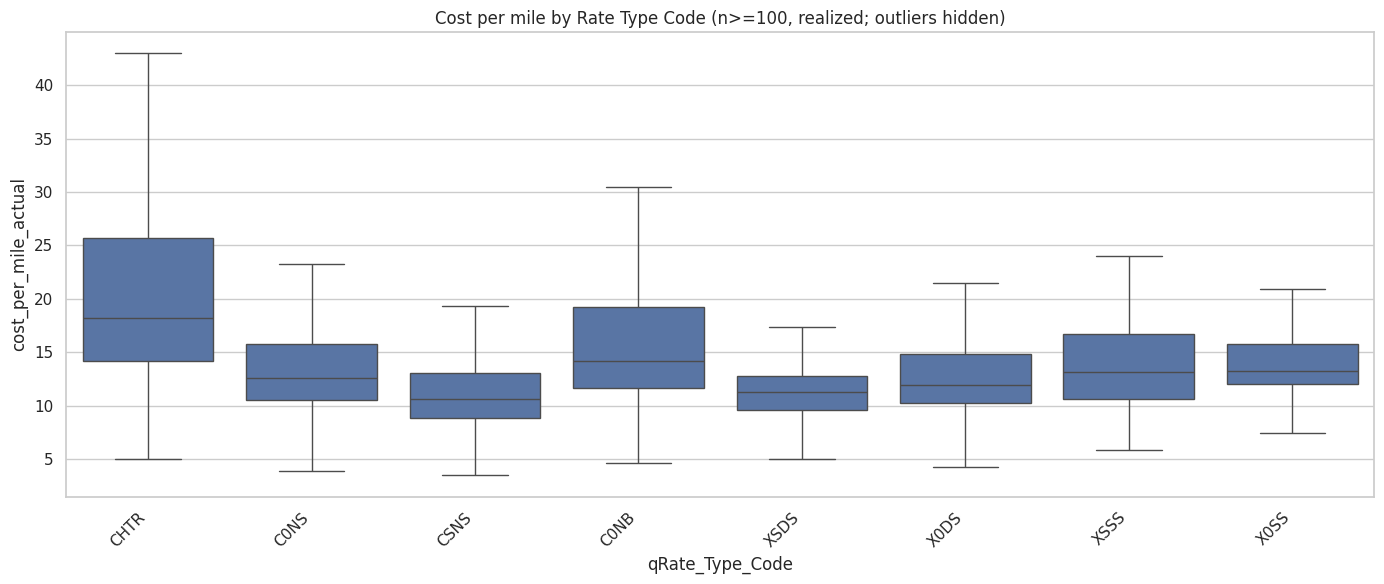

In [24]:
# --- Rate code / trip type effects (toggle candidates) ---
# Keep only reasonably frequent categories for readability
min_n = 100
rate_counts = plot_df['qRate_Type_Code'].astype('string').fillna('NA').value_counts()
rate_keep = rate_counts[rate_counts >= min_n].index.tolist()
plot_rate = plot_df[plot_df['qRate_Type_Code'].astype('string').fillna('NA').isin(rate_keep)].copy()
plot_rate['qRate_Type_Code'] = plot_rate['qRate_Type_Code'].astype('string').fillna('NA')

plt.figure(figsize=(14, 6))
order = plot_rate['qRate_Type_Code'].value_counts().index
sns.boxplot(data=plot_rate, x='qRate_Type_Code', y='cost_per_mile_actual', showfliers=False, order=order)
plt.title(f'Cost per mile by Rate Type Code (n>={min_n}, realized; outliers hidden)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [25]:
# Quick table: median unit economics by rate code (interpretable for pricing toggles)
rate_summary = (
    plot_rate.groupby('qRate_Type_Code')
    .agg(
        n=('Trip_Number','size'),
        med_cpm=('cost_per_mile_actual','median'),
        med_cph=('cost_per_block_hr_actual','median'),
        med_miles=('miles_total','median'),
        med_block_hr=('block_hr_total','median'),
        med_dh_share=('dh_share_miles','median'),
        med_margin_pct=('margin_pct_vs_ac_cost','median')
    )
    .sort_values('n', ascending=False)
)

display(rate_summary.round(3))


,n,med_cpm,med_cph,med_miles,med_block_hr,med_dh_share,med_margin_pct
qRate_Type_Code,,,,,,,
CHTR,862,18.260,6353.234,1183.0,3.333,0.000,0.172
C0NS,778,12.625,5236.010,2299.0,5.467,0.079,0.279
CSNS,388,10.655,4486.136,2246.5,5.142,0.104,0.259
C0NB,377,14.216,5487.002,2286.0,5.650,0.102,0.260
XSDS,342,11.326,4798.644,2198.0,4.867,0.022,-0.247
X0DS,196,11.965,5371.892,2328.0,5.183,0.032,-0.124
XSSS,189,13.197,5749.586,2270.0,5.217,0.023,-0.031
X0SS,145,13.279,6138.514,2379.0,5.100,0.009,0.030


In [28]:
%%geminicli_magic
Help me understand the trip_cln dataframe.


✨ Code generated and placed in the cell below.


In [ ]:
trip_cln.head()
trip_cln.info()
trip_cln.describe()
trip_cln.isnull().sum()
trip_cln.columns